# Visualisierung mit Matplotlib

Matplotlib ist eine leistungsstarke Python-Bibliothek zur Erstellung von statischen, animierten und interaktiven Visualisierungen. 
Leider ist die Bedienung manchmal etwas umständlich und unübersichtlich. 

- Hier lohnt sich der Einsatz von CoPilot besonders 
    - Viele verschiedene Funktionen die schwer zu überblicken sind
    - Fehler fallen sofort auf (die Darstellung ist nicht wie erwartet)


### Matplotlib installieren und importieren

Meistens muss Matplotlib zuerst installiert werden. Dies geschieht mit dem Befehl:

```bash
pip install matplotlib
```

Das `pyplot`-Submodul ist für die meisten Visualisierungen zuständig. Es wird üblicherweise mit dem Alias `plt` importiert.

In [2]:
import matplotlib.pyplot as plt

## Einfaches Plotten: `plt.plot()`

Die einfachste Art ist der Linienplot.
- Die Funktion `plot()` wird für Linienplots verwendet
- `title` gibt dem Plot einen Titel
- `xlabel` und `ylabel` beschriften die Achsen des Plots
- `show()` zeigt auf dem Bildschirm an



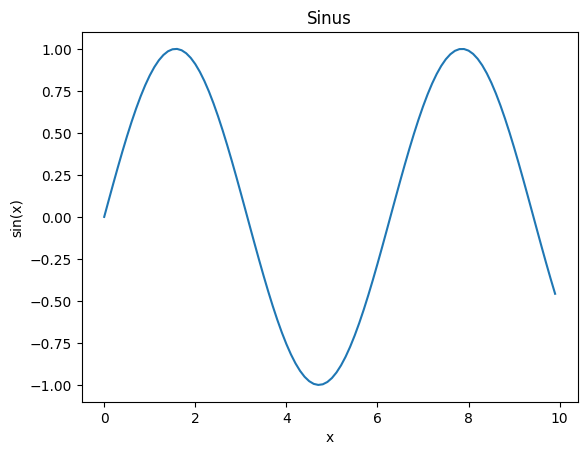

In [7]:
from math import sin, cos
x = [i * 0.1 for i in range(100)]
y = [sin(xi) for xi in x]

plt.plot(x, y)
plt.title('Sinus')
plt.xlabel('x')
plt.ylabel('sin(x)')
plt.show()

Man kann mehrere Linien in einem Plot darstellen, indem man einfach mehrere `plot()`-Aufrufe hintereinander ausführt.
- Um die Linien zu unterscheiden kann man den Befehl `label` verwenden
- Mit `legend()` wird eine entsprechende Legende hinzugefügt
    - Die Position der Legende kann mit dem Parameter `loc` angepasst werden
    - Mögliche Werte sind z.B. 'upper right', 'lower left', 'best', etc.

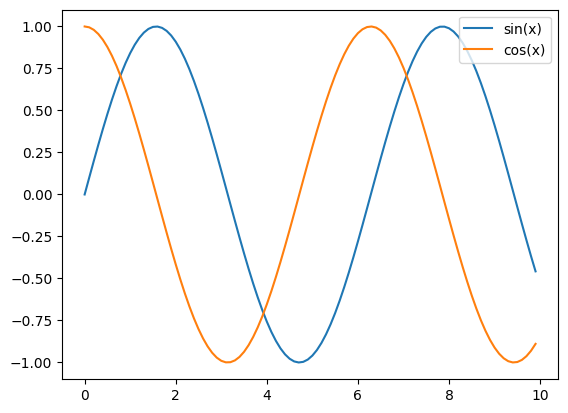

In [12]:
plt.plot(x, y, label='sin(x)')
plt.plot(x, [cos(xi) for xi in x], label='cos(x)')
plt.legend(loc='upper right')
plt.show()

### Wachstum visualisieren mit `plt.loglog()` und `plt.semilogy()`
Manchmal ist es sinnvoll, eine logarithmische Skalierung der Achsen zu verwenden, um das Wachstum von Funktionen besser zu visualisieren.
- `loglog()` verwendet eine logarithmische Skalierung für beide Achsen
- `semilogy()` verwendet eine logarithmische Skalierung nur für die y-Achse 
- `semilogx()` verwendet eine logarithmische Skalierung nur für die x-Achse


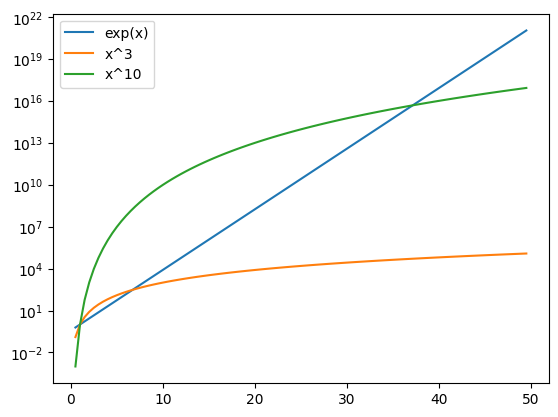

In [16]:
from math import exp
x = [i/2 for i in range(1, 100)]
plt.loglog(x, [exp(i-1) for i in x], label='exp(x)')
plt.loglog(x, [i**3 for i in x], label='x^3')
plt.loglog(x, [i**10 for i in x], label='x^10')
plt.legend()
plt.show()

### Flächen füllen mit `plt.fill()`
Wenn man eine Fläche mit Farbe füllen möchte, kann man die Funktion `fill()` verwenden.
- `fill(x, y)` füllt die Fläche, die durch die Punkte `(x[i], y[i])` definiert ist
- `color` definiert die Farbe der Fläche
- `alpha` definiert die Transparenz der Fläche (0 = transparent, 1 = undurchsichtig)

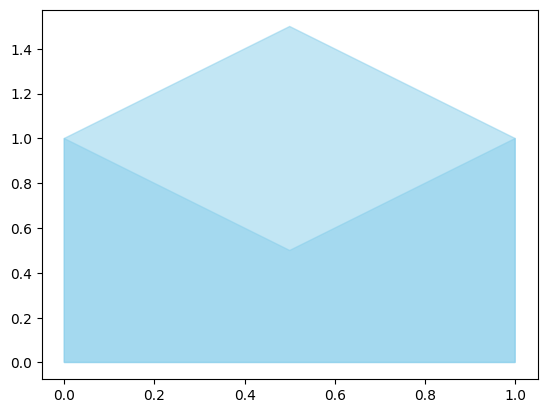

In [21]:
import matplotlib.pyplot as plt
plt.fill([0,1,1,0.5,0], [0,0,1,0.5,1], color='skyblue', alpha=0.5)
plt.fill([0,1,1,0.5,0], [0,0,1,1.5,1], color='skyblue', alpha=0.5)
plt.show()

## Streudiagramme: `plt.scatter()`
Um die Beziehung zwischen zwei Variablen zu visualisieren, sind Streudiagramme nützlich.
- Die Funktion `scatter()` wird für Streudiagramme verwendet
- `c` kann verwendet werden, um die Farbe der Punkte basierend auf einer dritten Variable zu ändern
- `s` steuert die Größe der Punkte
- `colorbar()` fügt eine Farbskala hinzu

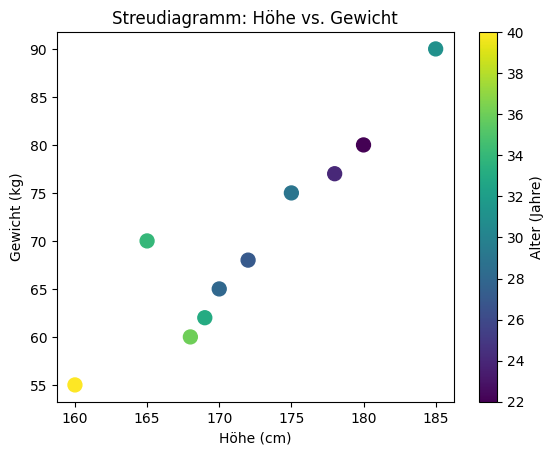

In [23]:
# Daten für 10 Personen: Höhe (cm), Gewicht (kg), Alter (Jahre), Ge
people_data = [
    [170, 65, 28],
    [165, 70, 34],
    [180, 80, 22],
    [175, 75, 29],
    [160, 55, 40],
    [185, 90, 31],
    [172, 68, 27],
    [168, 60, 36],
    [178, 77, 24],
    [169, 62, 33]
]

plt.scatter([person[0] for person in people_data], [person[1] for person in people_data], c=[person[2] for person in people_data], s=100)
plt.colorbar(label='Alter (Jahre)')
plt.title('Streudiagramm: Höhe vs. Gewicht')
plt.xlabel('Höhe (cm)')
plt.ylabel('Gewicht (kg)')
plt.show()

## Balkendiagramme: `plt.bar()`
Balkendiagramme sind nützlich, um kategorische Daten zu visualisieren.
- Die Funktion `bar()` wird für Balkendiagramme verwendet

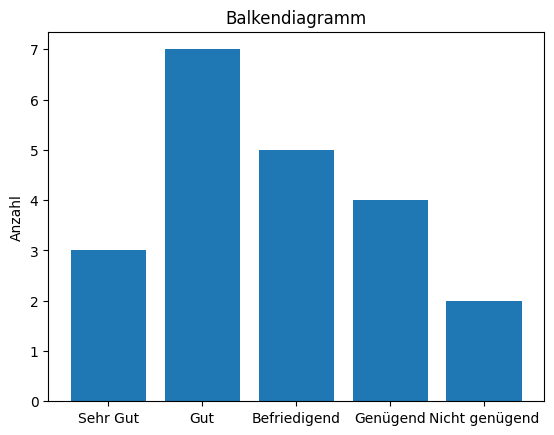

In [8]:
categories = ['Sehr Gut', 'Gut', 'Befriedigend', 'Genügend', 'Nicht genügend']
values = [3, 7, 5, 4, 2]
plt.bar(categories, values)
plt.title('Balkendiagramm')
plt.ylabel('Anzahl')
plt.show()

## Histogramme: `plt.hist()`
Um die Anzahl von Datenpunkten in verschiedenen Bereichen zu visualisieren, sind Histogramme nützlich.
- Die Funktion `hist()` wird für Histogramme verwendet
- `bins` steuert die Anzahl der Balken im Histogramm
- `bins` kann auch eine Liste von Zahlen sein, die die Grenzen der Balken definieren


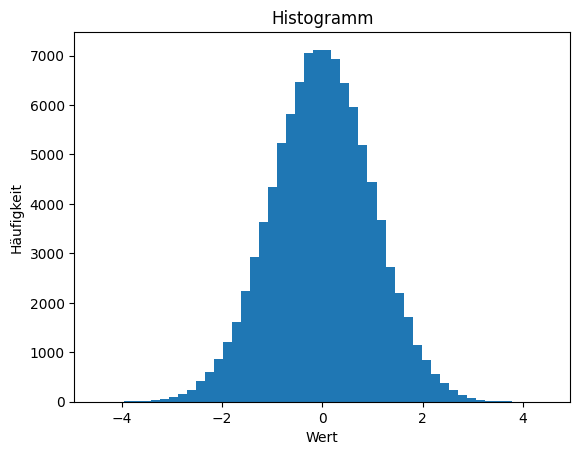

In [28]:
import random as rnd
data = [rnd.gauss(0, 1) for _ in range(100000)]
plt.hist(data, bins=50)
plt.title('Histogramm')
plt.xlabel('Wert')
plt.ylabel('Häufigkeit')
plt.show()

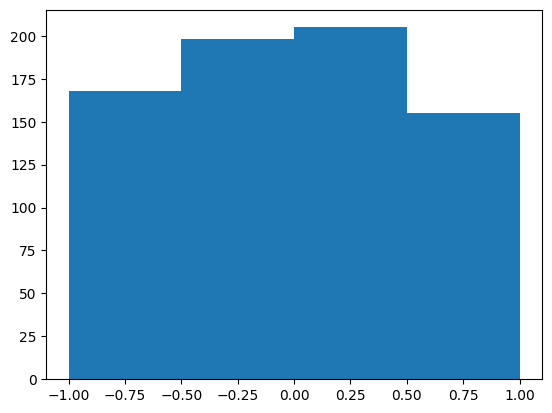

In [10]:
plt.hist(data, bins=[-1,-0.5,0,0.5,1])
plt.show()

### Mehrere Plots in einem Bild `plt.subplot()` und `plt.subplots()`
Die Funktion `subplots()` erstellt eine Figur und ein Gitter von Subplots.
- Die ersten beiden Parameter `nrows` und `ncols` geben die Anzahl der Zeilen und Spalten an
- `figsize` steuert die Größe der gesamten Figur (in Inches)
- `subplot()` wird verwendet, um einen bestimmten Subplot zu aktivieren
    - `nrows`, `ncols` und `index` geben die Position des Subplots an
        - man kann stattdess auch einen Parameter wie `121` verwenden, der für 1 Zeile, 2 Spalten und den ersten Subplot steht
    - `nrows` und `ncols` muss mit den Werten in `subplots()` übereinstimmen
    - `index` ist die laufende Nummer des Subplots (von links nach rechts, oben nach unten)

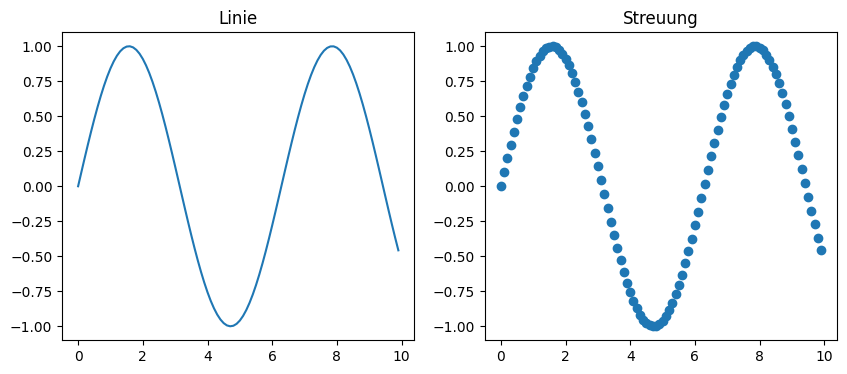

In [30]:
from math import sin, cos
x = [i * 0.1 for i in range(100)]
y = [sin(xi) for xi in x]
plt.subplots(1, 2, figsize=(10, 4))
# Plot 1: Linienplot
plt.subplot(1, 2, 1)
plt.plot(x, y)
plt.title('Linie')
# Plot 2: Streudiagramm
plt.subplot(1, 2, 2)
plt.scatter(x, y)
plt.title('Streuung')
plt.show()

### `Axes` Objekte erstellen

Bis jetzt haben wir die `pyplot`-Schnittstelle verwendet, die eine einfache Möglichkeit bietet, Plots zu erstellen.
- Manchmal ist es jedoch nützlich, direkt mit `Axes`-Objekten zu arbeiten, um mehr Kontrolle über die Plots zu haben.
- `fig, ax = plt.subplots()` erstellt eine Figur und ein einzelnes `Axes`-Objekt
- `ax.plot()` wird verwendet, um auf dem `Axes`-Objekt zu plotten
- `ax.set_title()`, `ax.set_xlabel()`, und `ax.set_ylabel()` werden verwendet, um Titel und Achsenbeschriftungen für das `Axes`-Objekt festzulegen
- `figsize` kann verwendet werden, um die Größe des Bildes anzupassen

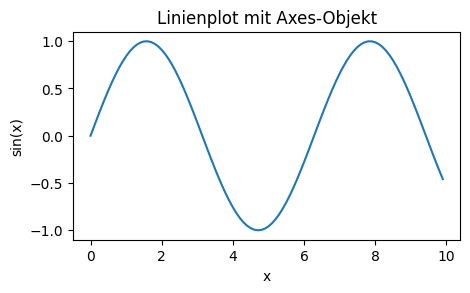

In [33]:
fig, ax = plt.subplots(figsize=(5, 2.7))
ax.plot(x, y)
ax.set_title('Linienplot mit Axes-Objekt')
ax.set_xlabel('x')   # Achtung: leicht unterschiedlich zu plt.xlabel()
ax.set_ylabel('sin(x)')
plt.show()


### Geometrische Figuren plotten
Matplotlib bietet auch Funktionen zum Zeichnen von geometrischen Figuren wie Kreisen, Rechtecken und Polygonen.
- `Circle`, `Rectangle` und `Polygon` sind Klassen, die geometrische Figuren repräsentieren
    - `alpha` steuert die Transparenz der Figur (0 = unsichtbar, 1 = undurchsichtig)
- Diese Figuren können zu einem Plot hinzugefügt werden, indem man sie als Patch-Objekte hinzufügt.
- `add_patch()` fügt die Figur dem aktuellen Plot hinzu

Die Methode `add_patch()` ist eine Methode des `Axes`-Objekts.
Man muss daher zuerst ein `Axes`-Objekt erstellen, z.B. mit `fig, ax = plt.subplots()`, und dann `ax.add_patch(...)` verwenden.

- Der Befehl `set_aspect('equal')` sorgt dafür, dass die Achsen gleich skaliert werden, sodass Kreise auch als Kreise dargestellt werden und nicht als Ellipsen.

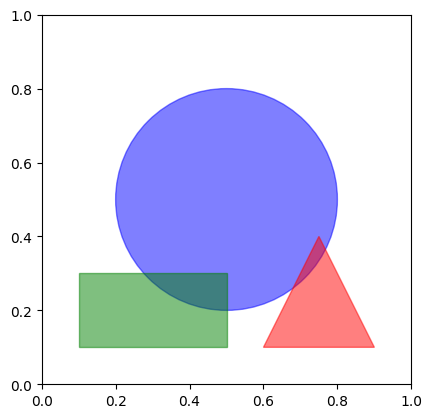

In [35]:
circle = plt.Circle((0.5, 0.5), 0.3, color='blue', alpha=0.5)
rectangle = plt.Rectangle((0.1, 0.1), 0.4, 0.2, color='green', alpha=0.5)
polygon = plt.Polygon([[0.6, 0.1], [0.9, 0.1], [0.75, 0.4]], color='red', alpha=0.5)
fig, ax = plt.subplots()
ax.add_patch(circle)
ax.add_patch(rectangle)
ax.add_patch(polygon)
ax.set_aspect('equal')
plt.show()

## Speichern von Abbildungen: `plt.savefig()`
Anstatt ein Bild am Bildschirm anzuzeigen, kann es auch in einer Datei gespeichert werden. Dazu wird die Funktion `plt.savefig()` verwendet.
Man kann ein Bild speichern und zusätzlich auf dem Bildschirm anzeigen.

- Der erste Parameter ist der Dateiname (inkl. Pfad)
- Das Dateiformat wird durch die Dateiendung bestimmt (z.B. `.png`, `.jpg`, `.pdf`, etc.)
- `dpi` steuert die Auflösung des Bildes    
- `bbox_inches='tight'` sorgt dafür, dass keine unnötigen weißen Ränder gespeichert werden
- `transparent=True` speichert das Bild mit transparentem Hintergrund (nur bei Formaten die Transparenz unterstützen, z.B. `.png`)
```python
plt.savefig('plot.png', dpi=300, bbox_inches='tight', transparent=True)
```


### Gestaltung von Plots
Matplotlib bietet viele Möglichkeiten, Plots anzupassen. Einfache Optionen sind z.B.: Farben, Marker, oder Linienstile

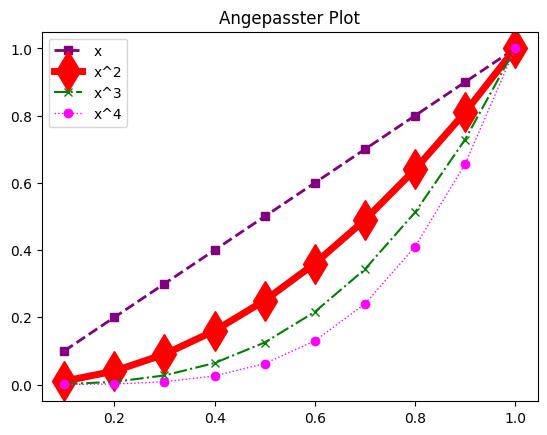

In [37]:
x = [0.1*i for i in range(1, 11)]
plt.plot(x, x, linestyle='--', marker='s', color='purple', linewidth=2, label='x')
plt.plot(x, [i**2 for i in x], linestyle='-', marker='d', color='red', linewidth=5, markersize = 20, label='x^2')
plt.plot(x, [i**3 for i in x], linestyle='-.', marker='x', color='green', label='x^3')
plt.plot(x, [i**4 for i in x], linestyle=':', marker='o', color='magenta',linewidth=1, label='x^4')
plt.legend()
plt.title('Angepasster Plot')
plt.show()

Für stilistische Anpassungen ist Copilot besonders hilfreich. Man kann mit einem einfachen Plot starten, z.b.
```python
plt.plot(x, x)
plt.plot(x, x**0.5)
plt.plot(x, x**2)
```
und dann mit einem Prompt der folgenden Art optimieren:
"Use different shades of blue for the three lines and use different line styles (solid, dashed, dotted). Add a legend to the plot."




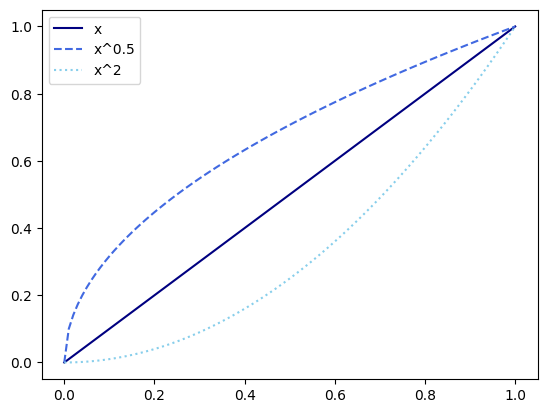

In [ ]:
x = [0.01*i for i in range(0, 101)]
plt.plot(x, x, color='navy', linestyle='-', label='x')
plt.plot(x, [i**0.5 for i in x], color='royalblue', linestyle='--', label='x^0.5')
plt.plot(x, [i**2 for i in x], color='skyblue', linestyle=':', label='x^2')
plt.legend()
plt.show()

## Animationen mit Matplotlib
Matplotlib unterstützt auch Animationen. Die einfache Methode ist die Verwendung von `plt.pause()` und `ax.clear()` in einer Schleife, um den Plot zu aktualisieren.
- `ax.clear()` löscht den aktuellen Plot
- `plt.pause(seconds)` pausiert die Ausführung für eine bestimmte Anzahl von Sekunden und aktualisiert den Plot
- Diese Methode ist nicht sehr effizient und daher nur für einfache Animationen geeignet

__Achtung:__ In Jupyter Notebooks funktioniert `plt.pause()` nicht immer zuverlässig. Es ist besser, Animationen in einem normalen Python-Skript auszuführen.


In [ ]:
import matplotlib.pyplot as plt
import random

fig, ax = plt.subplots(1,1)
def bubble_sort(arr):
    n = len(arr)
    for i in range(n):
        for j in range(0, n-i-1):            
            if arr[j] > arr[j+1]:
                arr[j], arr[j+1] = arr[j+1], arr[j]
            ax.clear()
            ax.bar(range(n), arr, color='lightblue')
            plt.pause(0.01)

n=40        
data = [random.random() for _ in range(n)]
bubble_sort(data)

<img src="illustrations/sort.gif"  width="400"/>

### Animation mit FuncAnimation
Eine effizientere Methode zur Erstellung von Animationen in Matplotlib ist die Verwendung der Klasse `FuncAnimation` aus dem Modul `matplotlib.animation`. Diese Methode ist besonders nützlich für komplexere Animationen, da sie den Plot nur bei Bedarf aktualisiert und so die Leistung verbessert.
- `FuncAnimation` benötigt eine Figur, eine Animationsfunktion und einen Intervall in Millisekunden
- Die Animationsfunktion `animate` wird für jeden Frame aufgerufen und erhält die aktuelle Bild-Nummer
    - Die Funktion verwendet das `line`-Objekt welches von `plot()` zurückgegeben wird, um die Daten zu aktualisieren
    - 'ax.plot()' gibt eine List von Linenobjekten zurück, auch wenn nur eine Linie gezeichnet wird. Daher wird das erste Element der Liste mit `[0]` ausgewählt.
- `frames` gibt den Bereich der Frames an, also `i in range(500)`


In [ ]:
from math import sin, pi
import matplotlib.animation as animation

fig, ax = plt.subplots()

x = [ 2*pi*i/10000 for i in range(1,10000)] 
line = ax.plot(x[5000:], [sin(1/i) for i in x[5000:]])[0]
ax.set_xlim(0, 2*pi)
ax.set_ylim(-1, 1)

def animate(i):
    line.set_xdata(x[5000-10*i:])  # update the x data.
    line.set_ydata([sin(1/j) for j in x[5000-10*i:]])  # update the y data.
    return line,


ani = animation.FuncAnimation(
    fig, animate, interval=20, frames=500)
ani.save('animation.gif', writer='pillow')
plt.show()


<img src="illustrations/animation2.gif" alt="Animation eines sich bewegenden Sinus" width="400"/>

### Weitere Informationen zu Matplotlib

Eine gute Resource ist die offizielle Matplotlib-Galerie https://matplotlib.org/stable/gallery/index.html
- Hier findet man viele Beispiele und Anleitungen für verschiedene Plot-Typen.
- Man sucht ein Beispiel welches dem gewünschten Plot ähnelt und passt es an.

### 3D Plots -> später
Im Kapitel 'Numerische Mathematik mit NumPy' werden wir auch noch Beispiele zu 3D Plots sehen.